## Setup and Imports

In [23]:
# Standard Libriaries

import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')  #Suppress minor warnings for cleaner output

# Custom modules
project_root = Path().resolve().parents[1] 
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
#from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Custom helper functions
from utils.helpers import load_orders, set_style, save_figure

set_style()

print('All imports successful✓')
print(f'pandas version: {pd.__version__}')
print(f'numpy version: {np.__version__}')



All imports successful✓
pandas version: 2.2.3
numpy version: 1.26.4


## Load and Validate Data

In [4]:
# Load the dataset

df_raw = load_orders(cleaned=False) # never modified
df = df_raw.copy()                  # working copy - safe to transform

print('Dataset Overview')
print(f'Rows:  {len(df):,}')
print(f'Columns:  {len(df.columns):,}')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  {col}')

Dataset Overview
Rows:  21,864
Columns:  12

Column names:
  USER_ID
  ORDER_ID
  PURCHASE_TS
  SHIP_TS
  PRODUCT_NAME
  PRODUCT_ID
  USD_PRICE
  PURCHASE_PLATFORM
  MARKETING_CHANNEL
  ACCOUNT_CREATION_METHOD
  COUNTRY_CODE
  REGION


In [5]:
df.head()

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION
0,2c06175e,0001328c3c220830,2020-12-24 00:00:00,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,NaN
1,ee8e5bc2,0002af7a5c6100772,2020-10-01 00:00:00,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE,EMEA
2,9eb4efe0,0002b8350e167074,2020-04-21 00:00:00,2020-02-16,Nintendo Switch,8d0d,151.20,website,direct,desktop,US,NaN
3,cac7cbaf,0006d06b98385729,2020-04-07 00:00:00,2020-04-04,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU,APAC
4,6b0230bc,00097279a2f46150,2020-11-24 00:00:00,2020-08-02,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR,EMEA


In [6]:
print('Data Types and Null Counts')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df.to_string())

Data Types and Null Counts
                                  dtype  null_count  null_pct
USER_ID                          object           0      0.00
ORDER_ID                         object           0      0.00
PURCHASE_TS                      object           0      0.00
SHIP_TS                  datetime64[ns]           0      0.00
PRODUCT_NAME                     object           0      0.00
PRODUCT_ID                       object           0      0.00
USD_PRICE                       float64           5      0.02
PURCHASE_PLATFORM                object           0      0.00
MARKETING_CHANNEL                object          83      0.38
ACCOUNT_CREATION_METHOD          object          83      0.38
COUNTRY_CODE                     object          38      0.17
REGION                           object       10531     48.17


In [7]:
# Parse the timestamp columns into proper datetime objects
# errors='coerce' means if a value cannot be parsed as a date,
# it becomes NaT (Not a Time) rather than crashing the whole operation

df['PURCHASE_TS'] = pd.to_datetime(df['PURCHASE_TS'], errors='coerce')
df['SHIP_TS'] = pd.to_datetime(df['SHIP_TS'], errors='coerce')

# Calculate fulfilment days: ship date minus purchase date
# Positive = normal (shipped after purchase)
# Zero     = same-day dispatch
# Negative = ANOMALY (shipped before purchase — impossible in reality)
df['FULFILMENT_DAYS'] = (df['SHIP_TS'] - df['PURCHASE_TS']).dt.days

print('Timestamps parsed successfully ✓')
print(f"Purchase TS range: {df['PURCHASE_TS'].min()} → {df['PURCHASE_TS'].max()}")
print(f"Ship TS range:     {df['SHIP_TS'].min()} → {df['SHIP_TS'].max()}")

Timestamps parsed successfully ✓
Purchase TS range: 2019-01-01 00:00:00 → 2021-02-28 00:00:00
Ship TS range:     2018-10-18 00:00:00 → 2021-11-16 00:00:00


## Quantify Anomalies

In [8]:
# Segment the data based on fulfilment days
# This gives clear picture of full distribution and highlights any anomalies or missing data

normal = df[df['FULFILMENT_DAYS'] > 0] # normal orders that shipped after purchase
same_day = df[df['FULFILMENT_DAYS'] == 0] # same-day orders that shipped on the purchase day
anomalies = df[df['FULFILMENT_DAYS'] < 0] # anomalies that shipped before purchase (impossible, likely data errors)
missing = df[df['FULFILMENT_DAYS'].isna()] # missing timestamps where either PURCHASE_TS or SHIP_TS is null, making fulfilment days impossible to calculate

total = len(df)

print('Fulfilment Days Segmentation')
print(f"{'Segment':<30} {'Count':>8} {'% of Total':>12}")
print('-' * 52)
print(f"{'Normal (shipped after purchase)':<30} {len(normal):>8,} {len(normal)/total*100:>11.2f}%")
print(f"{'Same Day (shipped on purchase day)':<30} {len(same_day):>8,} {len(same_day)/total*100:>11.2f}%")
print(f"{'Anomalies (shipped BEFORE purchase)':<30} {len(anomalies):>8,} {len(anomalies)/total*100:>11.2f}%")
print(f"{'Missing timestamps':<30} {len(missing):>8,} {len(missing)/total*100:>11.2f}%")
print('-' * 52)
print(f"{'Total':<30} {total:>8,} {'100.0%':>12}")

Fulfilment Days Segmentation
Segment                           Count   % of Total
----------------------------------------------------
Normal (shipped after purchase)   19,857       90.82%
Same Day (shipped on purchase day)        5        0.02%
Anomalies (shipped BEFORE purchase)    1,997        9.13%
Missing timestamps                    5        0.02%
----------------------------------------------------
Total                            21,864       100.0%


In [9]:
# Analyze the anomalous records in more detail to understand the severity of the data issues

print('Anomalous Records - Fulfilment Days Statistics')
stats = anomalies['FULFILMENT_DAYS'].describe()
print(f" Most extreme:   {stats['min']:.0f} days (shipped {abs(stats['min']):.0f} days BEFORE purchase)")
print(f" Median:         {stats['50%']:.0f} days")
print(f" Mean:           {stats['mean']:.1f} days")
print(f" 75th pct:       {stats['75%']:.0f} days")
print()

# Distribution of anomaly severity
# - how many records are just slightly negative (e.g., -1 day) vs. how many are extreme (e.g., -30 days or more)

print(' Distribution of Anomaly Severity')
bins = [
    ('1 day before purchase', anomalies[anomalies['FULFILMENT_DAYS'] == -1]),  # shipped 1 day before purchase
    ('2-7 days before purchase', anomalies[(anomalies['FULFILMENT_DAYS'] >= -7) & (anomalies['FULFILMENT_DAYS'] < -1)]),  # shipped 2 to 7 days before purchase
    ('1-4 weeks before purchase', anomalies[(anomalies['FULFILMENT_DAYS'] >= -30) & (anomalies['FULFILMENT_DAYS'] < -7)]),  # shipped 8 to 30 days before purchase
    ('1-3 months before purchase', anomalies[(anomalies['FULFILMENT_DAYS'] >= -90) & (anomalies['FULFILMENT_DAYS'] < -30)]),  # shipped 31 to 90 days before purchase
    ('Over 3 months before purchase', anomalies[anomalies['FULFILMENT_DAYS'] < -90])  # shipped more than 90 days before purchase
]
for label, subset in bins:
    print(f"  {label:<25} {len(subset):>6,} records  ({len(subset)/len(anomalies)*100:.1f}%)")

Anomalous Records - Fulfilment Days Statistics
 Most extreme:   -642 days (shipped 642 days BEFORE purchase)
 Median:         -75 days
 Mean:           -74.9 days
 75th pct:       -36 days

 Distribution of Anomaly Severity
  1 day before purchase         15 records  (0.8%)
  2-7 days before purchase      78 records  (3.9%)
  1-4 weeks before purchase    328 records  (16.4%)
  1-3 months before purchase    767 records  (38.4%)
  Over 3 months before purchase    809 records  (40.5%)


## Pattern Investigation

In [12]:
# Flag each record for comparison between anomalies and normal orders, to facilitate further analysis and visualisation
# Binary flag column to indicate whether a record is anomalous or not, based on the fulfilment days

df['IS_ANOMALY'] = df['FULFILMENT_DAYS'] < 0

# Pattern 1: By Purchase platform
# Are anomalies more common on website vs mobile app? This could indicate platform-specific data issues or user behavior differences.
# If mobile app has far more anomalies, 
# it might suggest a bug in the app's timestamp handling or a user behavior pattern that leads to more data issues. 
# Conversely, if the website has more anomalies, it could point to issues in the web order processing system.

print('Anomalies by Purchase Platform')
platform_analysis = df.groupby('PURCHASE_PLATFORM').agg(
    total_orders=('ORDER_ID', 'count'),
    anomalies_count=('IS_ANOMALY', 'sum')
).assign(
    anomaly_rate = lambda x: (x['anomalies_count'] / x['total_orders'] * 100).round(1)
).sort_values('anomaly_rate', ascending=False)
print(platform_analysis.to_string())

Anomalies by Purchase Platform
                   total_orders  anomalies_count  anomaly_rate
PURCHASE_PLATFORM                                             
website                   19783             1815           9.2
mobile app                 2081              182           8.7


In [11]:
# Pattern 2: By Product
# Are certain products more prone to anomalies?
# If a specific product (e.g., "iPhone 12") has a much higher anomaly rate than others, 
# it could indicate product-specific data issues, such as a particular supplier's data feed being
# more error-prone, or it could reflect real-world differences in how certain products are processed and shipped
# or it might suggest a data entry issue with that SKU

print('Anomalies by Product')
product_analysis = df.groupby('PRODUCT_NAME').agg(
    total_orders=('ORDER_ID', 'count'),
    anomalies_count=('IS_ANOMALY', 'sum')
).assign(
    anomaly_rate = lambda x: (x['anomalies_count'] / x['total_orders'] * 100).round(1)
).sort_values('anomaly_rate', ascending=False)
print(product_analysis.to_string())

Anomalies by Product
                                total_orders  anomalies_count  anomaly_rate
PRODUCT_NAME                                                               
Razer Pro Gaming Headset                   7                1          14.3
Acer Nitro V Gaming Laptop                87               10          11.5
Lenovo IdeaPad Gaming 3                  669               68          10.2
27in 4K gaming monitor                  4662              441           9.5
Nintendo Switch                        10386              945           9.1
Dell Gaming Mouse                        719               65           9.0
JBL Quantum 100 Gaming Headset          4296              380           8.8
Sony PlayStation 5 Bundle                977               84           8.6
27inches 4k gaming monitor                61                3           4.9


In [13]:
# Pattern 3: By top 15 countries
# Geographic concentration may indicate a timezone issue
# e.g. a country far from UTC might have timestamps recorded in local time 
# but interpreted as UTC, leading to systematic negative fulfilment days for orders from that country
print('Anomalies by Country (Top 15 based on order volume)')
country_analysis = df.groupby('COUNTRY_CODE').agg(
    total_orders=('ORDER_ID', 'count'),
    anomalies_count=('IS_ANOMALY', 'sum')
).assign(
    anomaly_rate = lambda x: (x['anomalies_count'] / x['total_orders'] * 100).round(1)
).sort_values('total_orders', ascending=False).head(15)
print(country_analysis.to_string())

Anomalies by Country (Top 15 based on order volume)
              total_orders  anomalies_count  anomaly_rate
COUNTRY_CODE                                             
US                   10294              966           9.4
GB                    1808              148           8.2
CA                     956               78           8.2
AU                     893               66           7.4
DE                     855               80           9.4
FR                     559               54           9.7
JP                     525               37           7.0
BR                     494               47           9.5
ES                     408               31           7.6
NL                     326               28           8.6
IT                     313               30           9.6
MX                     274               26           9.5
IN                     261               31          11.9
CH                     197               24          12.2
KR                  

In [14]:
# Pattern 4: By month/year
# Did anomalies rate change over time? 
# A sudden spike in anomalies during a specific month or year could indicate a data processing issue that started at that time, 
# such as a software update that introduced a bug in timestamp handling, 
# or a change in the order processing system that affected how timestamps are recorded.

print('Anomalies by Month/Year')
df['YEAR_MONTH'] = df['PURCHASE_TS'].dt.to_period('M')  # extract year and month from purchase timestamp

time_analysis = df.groupby('YEAR_MONTH').agg(
    total_orders=('ORDER_ID', 'count'),
    anomalies_count=('IS_ANOMALY', 'sum')
).assign(
    anomaly_rate = lambda x: (x['anomalies_count'] / x['total_orders'] * 100).round(1)
)
print(time_analysis.to_string())

Anomalies by Month/Year
            total_orders  anomalies_count  anomaly_rate
YEAR_MONTH                                             
2019-01              469                0           0.0
2019-02              320                0           0.0
2019-03              521               62          11.9
2019-04              534               49           9.2
2019-05              501               37           7.4
2019-06              472               56          11.9
2019-07              554               35           6.3
2019-08              575               59          10.3
2019-09              681               70          10.3
2019-10              504               48           9.5
2019-11              681               82          12.0
2019-12              799               69           8.6
2020-01              357               34           9.5
2020-02              653               75          11.5
2020-03              988               94           9.5
2020-04             1189

In [15]:
# Pattern 5: Marketing channel
# Are anomalies more common in orders that came through certain marketing channels?

print('Anomalies by Marketing Channel')
channel_analysis = df.groupby('MARKETING_CHANNEL').agg(
    total_orders=('ORDER_ID', 'count'),
    anomalies_count=('IS_ANOMALY', 'sum')
).assign(
    anomaly_rate = lambda x: (x['anomalies_count'] / x['total_orders'] * 100).round(1)
).sort_values('anomaly_rate', ascending=False)
print(channel_analysis.to_string())

Anomalies by Marketing Channel
                   total_orders  anomalies_count  anomaly_rate
MARKETING_CHANNEL                                             
social media                323               41          12.7
direct                    17434             1601           9.2
affiliate                   721               65           9.0
email                      3256              281           8.6
unknown                      47                3           6.4


## Visualisations

Figure saved → reports/figures/01_fulfilment_status_overview.png


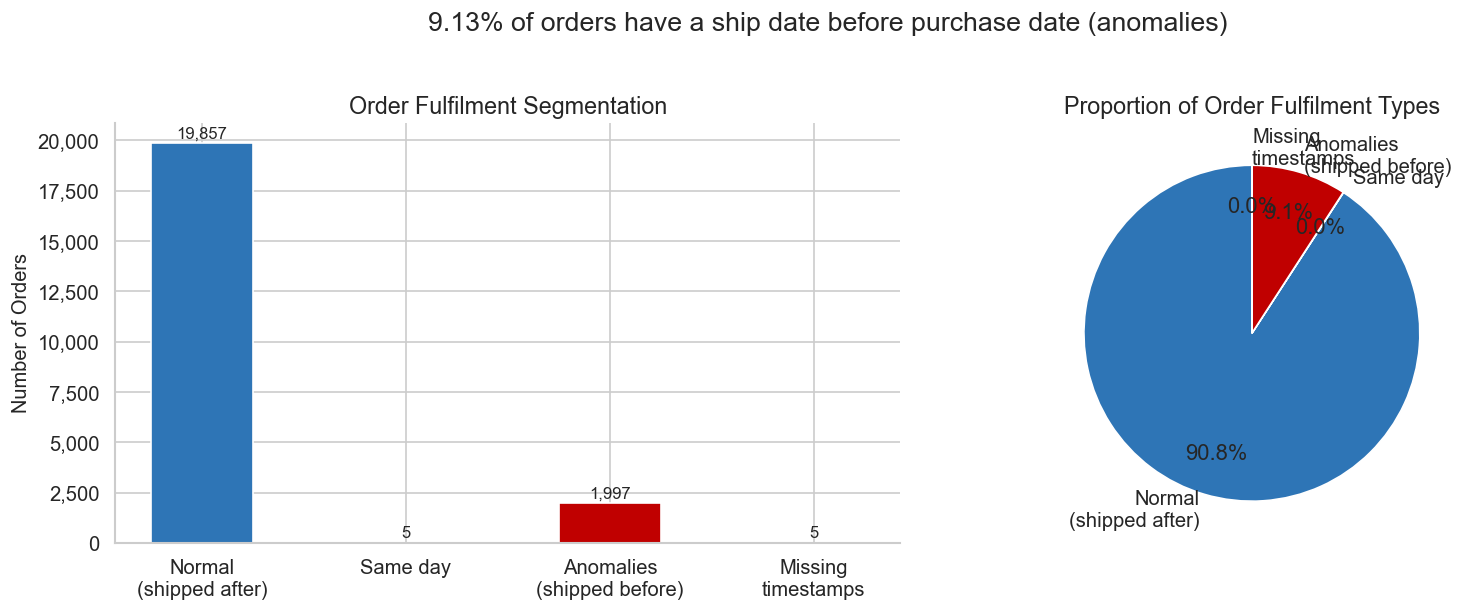

In [24]:
# Chart 1 Overall segmentation
# Show scale of problem at a glance - how many orders are normal vs same-day vs anomalies vs missing timestamps


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segments = ['Normal\n(shipped after)', 'Same day', 'Anomalies\n(shipped before)', 'Missing\ntimestamps']
counts = [len(normal), len(same_day), len(anomalies), len(missing)]
colours = ['#2E75B6', '#70AD47', '#C00000', '#808080']

bars = axes[0].bar(segments, counts, color=colours, width=0.5)
axes[0].set_title('Order Fulfilment Segmentation', fontsize=14, fontweight='medium')
axes[0].set_ylabel('Number of Orders', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))  # format y-axis with commas

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 100,  # position label slightly above the bar
        f'{count:,}', 
        ha='center', va='bottom', fontsize=10
    )
    
# Pie chart showing proportions
axes[1].pie(
    counts, 
    labels=segments, 
    colors=colours, 
    autopct='%1.1f%%', 
    startangle=90,
    pctdistance=0.75,  # position percentage labels closer to the center
)
axes[1].set_title('Proportion of Order Fulfilment Types', fontsize=14, fontweight='medium')

fig.suptitle(f"{len(anomalies)/total*100:.2f}% of orders have a ship date before purchase date (anomalies)", 
                    fontsize=16, fontweight='medium', y=1.02)

save_figure(fig, '01_fulfilment_status_overview.png')
plt.show()